In [69]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import matplotlib.cm as cm

## Disk cylindrical
12/18/25: Running the cylindrical disk.

- Used this configuration: `python configure.py --prob=disk --coord=cylindrical --eos=isothermal -hdf5 -h5double -mpi --hdf5_path /hpc/software/spack_v20d1/spack/opt/spack/linux-rhel7-x86_64/intel-2021.4.0/hdf5-1.10.7-exmishiaff3ugqbeeimkqvnwrir76sxh -omp --cflag=-qno-openmp-simd`
- Used `athinput.disk_cyl` input file, editing tlim to 12 (seconds, I assume) and file_type to hdf5 under `<output1>`.

In [70]:
file_path = "disk.out1.00001.athdf"

with h5py.File(file_path, "r") as f:
    # Print all root level object names (aka keys) 
    # these can be group or dataset names 
    print("Keys: %s" % f.keys())
    # get first object name/key; may or may NOT be a group
    a_group_key = list(f.keys())[0]

    # get the object type for a_group_key: usually group or dataset
    print(type(f[a_group_key])) 

    # If a_group_key is a group name, 
    # this gets the object names in the group and returns as a list
    data = list(f[a_group_key])

    # If a_group_key is a dataset name, 
    # this gets the dataset values and returns as a list
    data = list(f[a_group_key])
    # preferred methods to get dataset values:
    ds_obj = f[a_group_key]      # returns as a h5py dataset object
    ds_arr = f[a_group_key][()]  # returns as a numpy array

    # cons = conserved variables (density, momenta, total energy, and cell-centered magnetic fields)
    conses = f['cons'][()] 
    x1vs = f['x1v'][()]
    x2vs = f['x2v'][()]
    x3vs = f['x3v'][()]

x1vs.shape

Keys: <KeysViewHDF5 ['Levels', 'LogicalLocations', 'cons', 'x1f', 'x1v', 'x2f', 'x2v', 'x3f', 'x3v']>
<class 'h5py._hl.dataset.Dataset'>


(1, 64)

In [71]:
x2vs

array([[0.01227185, 0.03681554, 0.06135923, 0.08590292, 0.11044662,
        0.13499031, 0.159534  , 0.18407769, 0.20862139, 0.23316508,
        0.25770877, 0.28225246, 0.30679616, 0.33133985, 0.35588354,
        0.38042724, 0.40497093, 0.42951462, 0.45405831, 0.47860201,
        0.5031457 , 0.52768939, 0.55223308, 0.57677678, 0.60132047,
        0.62586416, 0.65040785, 0.67495155, 0.69949524, 0.72403893,
        0.74858262, 0.77312632, 0.79767001, 0.8222137 , 0.84675739,
        0.87130109, 0.89584478, 0.92038847, 0.94493217, 0.96947586,
        0.99401955, 1.01856324, 1.04310694, 1.06765063, 1.09219432,
        1.11673801, 1.14128171, 1.1658254 , 1.19036909, 1.21491278,
        1.23945648, 1.26400017, 1.28854386, 1.31308755, 1.33763125,
        1.36217494, 1.38671863, 1.41126232, 1.43580602, 1.46034971,
        1.4848934 , 1.5094371 , 1.53398079, 1.55852448, 1.58306817,
        1.60761187, 1.63215556, 1.65669925, 1.68124294, 1.70578664,
        1.73033033, 1.75487402, 1.77941771, 1.80

In [72]:
conses.shape

(4, 1, 1, 256, 64)

In [81]:
ps = conses[1,0,0,:,:] # first index determines which variable we plot

In [82]:
# we want thetas, rs to each be 256x64
thetas, rs = np.meshgrid(x2vs.flatten(), x1vs.flatten(),\
                        indexing='ij') # x2vs is 256 elements, x1vs is 64 elements

In [78]:
thetas.shape

(256, 64)

[Example of a scatter plot on a polar grid](https://matplotlib.org/stable/gallery/pie_and_polar_charts/polar_scatter.html)

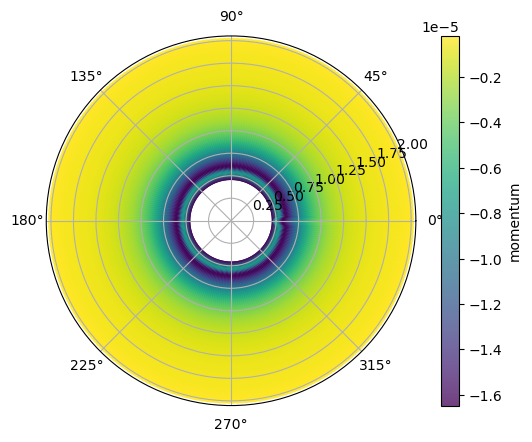

In [84]:
# Fixing random state for reproducibility
# np.random.seed(19680801)

# # Compute areas and colors
# N = 150
# r = 2 * np.random.rand(N)
# theta = 2 * np.pi * np.random.rand(N)
# area = 200 * r**2
# colors = theta

fig = plt.figure()
ax = fig.add_subplot(projection='polar')
#c = ax.scatter(theta, r, c=colors, cmap='viridis', alpha=0.75)
c = ax.scatter(thetas, rs, c=ps, cmap='viridis', alpha=0.75)

# ax = fig.add_subplot()
# ax.pcolormesh(thetas, rs, rhos.T)

fig.colorbar(c, ax=ax, label="momentum")

save_fig = False
if save_fig:
    plt.savefig("Figs/disk-rho12.png")

plt.show()

## 1D Sod Shock Tube

12/18/25: Ran the 1D Sod shock tube test problem ([link](https://github.com/PrincetonUniversity/athena/wiki/1D-Shock-Tube)), and plotted density vs. position below.

In [39]:
file_path = "Sod.block0.out1.00025.tab"

x = pd.read_csv(file_path, sep=" ", skiprows=[0,1],names=["i",\
    "x1v", "rho", "press", "vel1", "vel2", "vel3"], skipinitialspace=True)

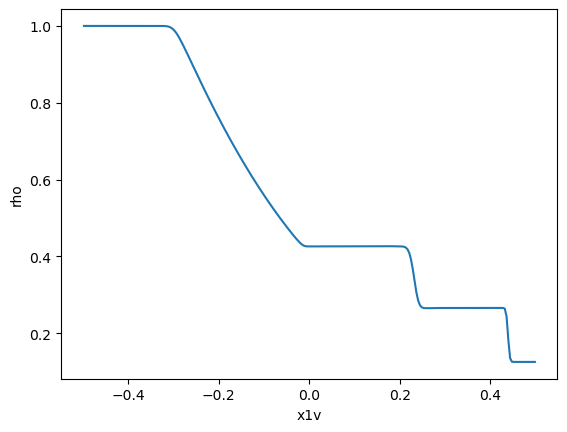

In [42]:
plt.plot(x["x1v"], x["rho"])
plt.xlabel("x1v")
plt.ylabel("rho")

plt.show()